## 01. ANOVA One Way, comparando com 3 grupos ou mais

In [1]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

In [2]:
df = pd.read_csv('../data/trailers_dados_aulas_1_e_2.csv')
df['tempo_visualizacao'] = df['tempo_visualizacao'].astype(int)
display(df.head())

,trailer_tipo,tempo_visualizacao
0,Drama,104
1,Drama,92
2,Drama,107
3,Drama,125
4,Drama,90


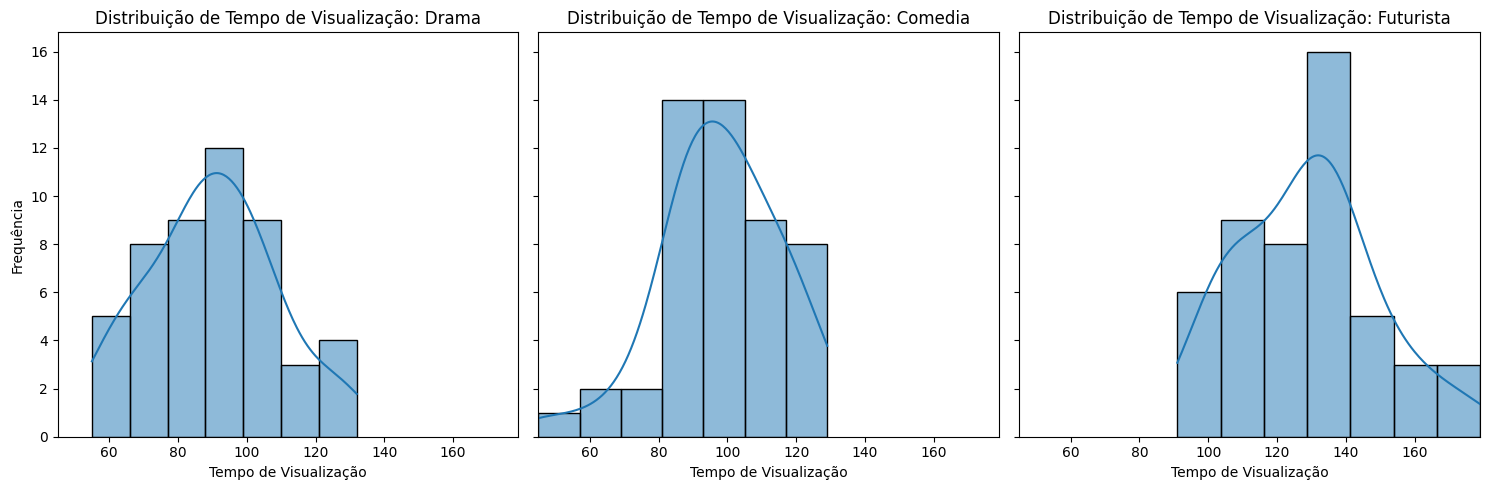

In [3]:
# Analise descritiva
import seaborn as sns
import matplotlib.pyplot as plt


# Mostrar tipos de trailers uncos
trailer_types = df['trailer_tipo'].unique()

# Criar subplots para cada tipo de trailer
fig, axes = plt.subplots(1, len(trailer_types), figsize=(15, 5), sharey=True)

# Plotar a distribuição de tempo de visualização para cada tipo de trailer
for i, trailer_types in enumerate(trailer_types):
    subset_df = df[df['trailer_tipo'] == trailer_types]
    sns.histplot(subset_df['tempo_visualizacao'], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribuição de Tempo de Visualização: {trailer_types}')
    axes[i].set_xlabel('Tempo de Visualização')
    axes[i].set_ylabel('Frequência')

# Ajusar todos  y-axes para ter a mesma escala
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, y_max)

# Ajustar todos x-axes para ter a mesma escala
x_min = df['tempo_visualizacao'].min()
x_max = df['tempo_visualizacao'].max()
for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()


In [4]:
# Agrupar por 'trailer_tipo' e calcular a media, desvio padrão e contagem
stats_table = df.groupby('trailer_tipo')['tempo_visualizacao'].agg(['mean', 'std', 'count']).reset_index()

# Renomear colunas para clareza
stats_table.rename(columns={'mean': 'media', 'std': 'desvio_padrao', 'count': 'numero_observacoes'}, inplace=True)

# Exibir a tabela resultante
display(stats_table)

,trailer_tipo,media,desvio_padrao,numero_observacoes
0,Comedia,97.90,17.521124,50
1,Drama,89.90,18.755407,50
2,Futurista,128.68,20.366479,50



Até aqui exploramos visualmente a distribuição do tempo de visualização por tipo de trailer e calculamos as estatísticas descritivas (média, desvio padrão e tamanho da amostra) para cada grupo, estamos prontos para realizar os cálculos necessários para a **Análise de Variância (ANOVA) One-Way**.

Nos próximos passos, vamos organizar os dados de forma adequada para o teste e, em seguida, executaremos a análise para determinar se há diferenças estatisticamente significativas nas médias de visualização entre os grupos de trailers.

### Estatística F e Distribuição F

A **Estatística F** é a razão entre a variância entre os grupos (MS_between) e a variância dentro dos grupos (MS_within). Ela é calculada usando a seguinte fórmula:

$$ F = \frac{MS_{between}}{MS_{within}} $$

Onde:
*   $ MS_{between} $: Quadrados Médios Entre Grupos
*   $ MS_{within} $: Quadrados Médios Dentro dos Grupos

Se a hipótese nula (de que as médias dos grupos são iguais) for verdadeira, a estatística F calculada seguirá uma **Distribuição F** com $df_{between}$ e $df_{within}$ graus de liberdade. Comparamos a estatística F calculada com os valores da distribuição F para determinar o p-valor.

In [5]:
import statsmodels.formula.api as smf
import statsmodels.stats.anova as anova
# ANOVA
model = smf.ols('tempo_visualizacao ~ C(trailer_tipo)', data=df).fit()
anova_table = anova.anova_lm(model, typ=2)

print(anova_table)

                       sum_sq     df         F        PR(>F)
C(trailer_tipo)  41921.613333    2.0  58.57436  1.958658e-19
Residual         52603.880000  147.0       NaN           NaN


### Observações ANOVA
*   A linha **`C(trailer_tipo)`** representa a variação **entre os grupos** (between-group). A soma dos quadrados entre os grupos é `41921.613333`.
*   A linha **`Residual`** representa a variação **dentro dos grupos** (within-group). A soma dos quadrados dentro dos grupos é `52603.880000`.

---
### Conclusao
Como o p-valor da ANOVA (1.958658e-19) é muito menor que 0.05, confirmamos que há diferenças estatisticamente significativas entre as médias de tempo de visualização dos grupos de trailers.

---

O código a seguir visualiza a distribuição F teórica esperada sob a hipótese nula e mostra onde a estatística F que você calculou a partir dos seus dados se encaixa nessa distribuição. Se a linha vertical do F calculado estiver na "cauda" direita da distribuição (longe do pico), isso sugere que o seu resultado é improvável de acontecer apenas por acaso, levando a um p-valor pequeno e à rejeição da hipótese nula.

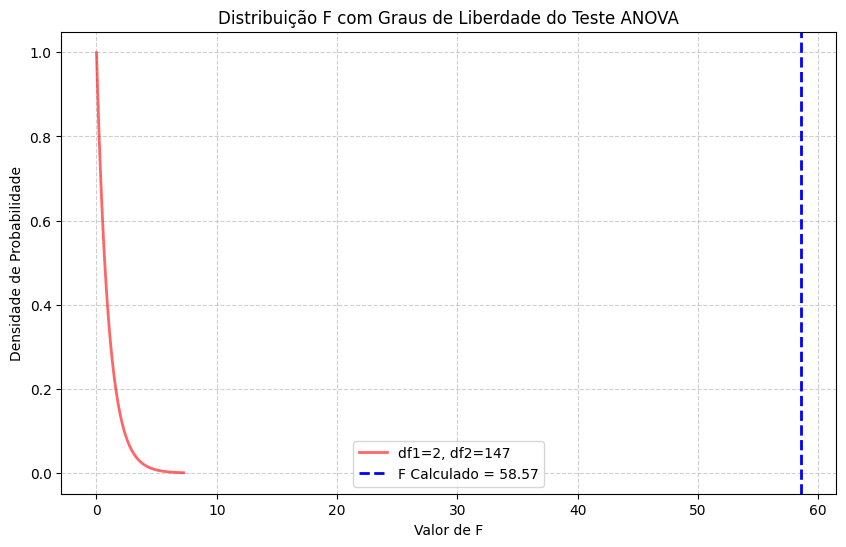

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Degrees of freedom from the ANOVA table
df_between = anova_table.loc['C(trailer_tipo)', 'df']
df_within = anova_table.loc['Residual', 'df']

# Define the range of x values for the plot
x = np.linspace(f.ppf(0.001, df_between, df_within),
                f.ppf(0.999, df_between, df_within), 100)
                
# Plot the F-distribution
plt.figure(figsize=(10, 6))
plt.plot(x, f.pdf(x, df_between, df_within),
         'r-', lw=2, alpha=0.6, label=f'df1={int(df_between)}, df2={int(df_within)}')

# Add a vertical line for the calculated F-statistic
f_calculated = anova_table.loc['C(trailer_tipo)','F']
plt.axvline(f_calculated, color='blue', linestyle='dashed', linewidth=2, label=f'F Calculado = {f_calculated:.2f}')

# Add title and labels
plt.title('Distribuição F com Graus de Liberdade do Teste ANOVA')
plt.xlabel('Valor de F')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 02. Téste Pós-HOC: Investigando diferenças específicas

### Teste Pós-Hoc de Tukey HSD

Como a ANOVA One-Way nos indicou que existem diferenças estatisticamente significativas entre as médias de tempo de visualização dos trailers, agora precisamos realizar testes pós-hoc para descobrir **quais pares específicos de grupos são diferentes entre si**.

O **Teste de Tukey Honest Significant Difference (HSD)** é um teste post-hoc comumente utilizado após uma ANOVA significativa. Ele compara as médias de todos os pares possíveis de grupos e ajusta os p-valores para controlar a taxa de erro Tipo I (a chance de declarar uma diferença significativa quando não há) ao fazer múltiplas comparações. Em essência, o Tukey HSD nos ajuda a identificar onde as diferenças reais estão localizadas após uma ANOVA geral.

A estatística do teste de Tukey HSD, frequentemente denotada por 'q', é calculada usando a seguinte fórmula:

$$ q = \frac{\bar{Y}_i - \bar{Y}_j}{\sqrt{\frac{MS_{within}}{n}}} $$

Onde:

*   $ \bar{Y}_i $ e $ \bar{Y}_j $: São as médias dos dois grupos que estão sendo comparados.
*   $ MS_{within} $ (Mean Square Within): É a variância dentro dos grupos, obtida da tabela ANOVA (o valor da linha "Residual" na coluna "MS"). Representa a variação aleatória dentro de cada grupo.
*   $ n $: É o tamanho da amostra em cada grupo. No caso do Tukey HSD "clássico", assume-se que os tamanhos das amostras são iguais em todos os grupos. Se os tamanhos das amostras forem diferentes, é comum usar uma versão modificada da fórmula que usa a média harmônica dos tamanhos das amostras.

A estatística 'q' calculada é então comparada a um valor crítico da distribuição studentized range para determinar se a diferença entre as médias dos grupos é estatisticamente significativa.

### Task
Calcule a estatística do teste de Tukey HSD manualmente e utilizando a função `pairwise_tukeyhsd` da biblioteca `statsmodels`. Compare os resultados e explique o significado de cada elemento na fórmula da estatística 'q'. Explique como encontrar o valor crítico na tabela Studentized Range.

### Calcular estatística 'q' manualmente

### Subtask:
Para cada par de grupos, calcular a estatística 'q' usando a fórmula: $ q = \frac{\bar{Y}_i - \bar{Y}j}{\sqrt{\frac{MS{within}}{n}}} $. Isso envolverá obter as médias dos grupos, o MS_within e o tamanho da amostra.


In [11]:
# Perform Tukey's HSD test using statsmodels
tukey_result = pairwise_tukeyhsd(endog=df['tempo_visualizacao'], groups=df['trailer_tipo'], alpha=0.05)
# Display the results using .summary()
print(tukey_result.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
Comedia     Drama     -8.0 0.0904 -16.9579  0.9579  False
Comedia Futurista    30.78    0.0  21.8221 39.7379   True
  Drama Futurista    38.78    0.0  29.8221 47.7379   True
---------------------------------------------------------



### Insights e observações
Observação1: Para Comedia vs Drama, o intervalo é [-16.9579, 0.9579]. Como este intervalo inclui zero (0 está entre -16.9579 e 0.9579), a diferença não é significativa (reject é False).

Observação2: {meandiff} = {Média do group2} - {Média do group1}

*   As diferenças estatisticamente significativas encontradas indicam que o tipo de trailer (Futurista vs Drama e Futurista vs Comédia) tem um efeito significativo no tempo de visualização. Esse resultado nos direciona para a produção de um filme futurista.

### Teste Pós-Hoc de Bonferroni

O **Teste de Bonferroni** é outro método de teste pós-hoc utilizado após uma ANOVA significativa para controlar a taxa de erro Tipo I ao realizar múltiplas comparações entre pares de grupos.

A correção de Bonferroni é mais simples do que o Tukey HSD. Ela ajusta o nível de significância ($\alpha$) para cada comparação individual dividindo o nível de significância original pelo número total de comparações par a par que estão sendo realizadas.

A fórmula para o novo nível de significância ajustado ($\alpha_{Bonferroni}$) é:

$$ \alpha_{Bonferroni} = \frac{\alpha_{original}}{m} $$

Onde:

*   $ \alpha_{original} $: É o nível de significância original (por exemplo, 0.05).
*   $ m $: É o número total de comparações par a par independentes. Para $k$ grupos, o número de comparações par a par é $ \frac{k(k-1)}{2} $.

Cada comparação individual é então testada para significância usando este novo nível de significância $\alpha_{Bonferroni}$. Se o p-valor de uma comparação for menor que $\alpha_{Bonferroni}$, a diferença é considerada estatisticamente significativa.

O método de Bonferroni é mais conservador (tem menos poder estatístico) do que o Tukey HSD, o que significa que é menos provável encontrar diferenças significativas, especialmente quando há muitas comparações. No entanto, ele é simples de entender e aplicar.

In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.stats.anova as anova
import pandas as pd
import scipy.stats as stats

# Assuming 'df' DataFrame is already loaded and contains 'trailer_tipo' and 'tempo_visualizacao'

# Perform pairwise t-tests
groups = df['trailer_tipo'].unique()
p_values = []
comparisons = []

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        data1 = df[df['trailer_tipo'] == group1]['tempo_visualizacao']
        data2 = df[df['trailer_tipo'] == group2]['tempo_visualizacao']

        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(data1, data2)

        p_values.append(p_value)
        comparisons.append(f'{group1} vs {group2}')

# Apply Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')

# Display the results
bonferroni_results = pd.DataFrame({
    'Comparação': comparisons,
    'P-valor Original': p_values,
    'P-valor Corrigido (Bonferroni)': pvals_corrected,
    'Rejeitar H0': reject
})

display(bonferroni_results)

,Comparação,P-valor Original,P-valor Corrigido (Bonferroni),Rejeitar H0
0,Drama vs Comedia,2.986472e-02,8.959417e-02,False
1,Drama vs Futurista,1.953331e-16,5.859993e-16,True
2,Comedia vs Futurista,1.542301e-12,4.626904e-12,True
